In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Install required libraries just in case
!pip install opencv-python numpy matplotlib scikit-learn torch torchvision

Mounted at /content/drive


Executing on: cpu
Niblack Sensitivity: 0.8461
Sauvola Sensitivity: 0.7492


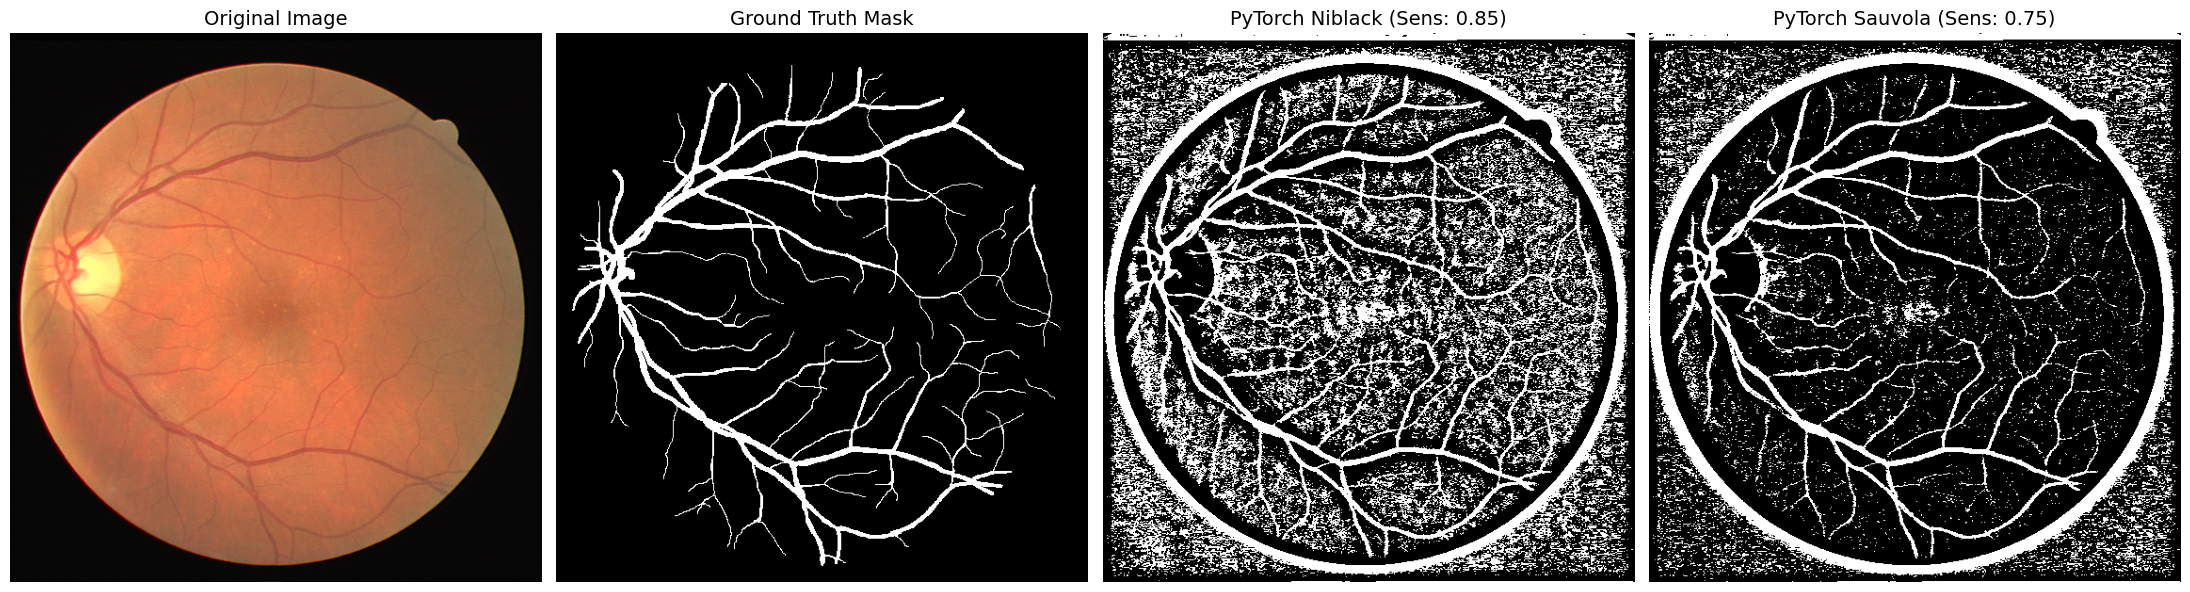

In [2]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import os

# --- 1. GPU Setup & Data Loading ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on: {device}")

# Path to your Google Drive folder
# Adjust this if your DRIVE folder is inside another folder!
base_path = "/content/drive/MyDrive/DRIVE"

# Hardcoding the first image for the assignment demonstration
image_path = os.path.join(base_path, "training/images/21_training.tif")
mask_path = os.path.join(base_path, "training/1st_manual/21_manual1.gif")

if not os.path.exists(image_path):
    print(f"Error: Could not find image at {image_path}. Check your Google Drive folder structure.")

img = cv2.imread(image_path)
ground_truth = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# --- 2. Preprocessing ---
# Retinal vessels have the highest contrast in the Green channel
green_channel = img[:, :, 1]

# Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to pop thin vessels
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced_green = clahe.apply(green_channel)

# Convert to PyTorch Tensor: Shape (Batch, Channel, Height, Width)
tensor_img = torch.tensor(enhanced_green, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)

# --- 3. PyTorch Local Statistics via Convolution ---
def get_pytorch_local_stats(tensor, window_size=25):
    pad = window_size // 2
    # Create a uniform mean filter
    weight = torch.ones((1, 1, window_size, window_size), dtype=torch.float32, device=device) / (window_size**2)

    # E[X] (Local Mean)
    local_mean = F.conv2d(tensor, weight, padding=pad)

    # E[X^2]
    local_mean_sq = F.conv2d(tensor**2, weight, padding=pad)

    # Variance = E[X^2] - (E[X])^2
    local_var = local_mean_sq - local_mean**2
    local_var = torch.clamp(local_var, min=0) # Prevent negative floating point errors
    local_std = torch.sqrt(local_var)

    return local_mean, local_std

mean, std = get_pytorch_local_stats(tensor_img, window_size=25)

# --- 4. Apply Mathematical Thresholds ---
# Niblack (vessels are dark, so we threshold below the mean by some standard deviations)
k_niblack = 0.2
T_niblack = mean - k_niblack * std
niblack_mask = (tensor_img < T_niblack).float().squeeze().cpu().numpy()

# Sauvola (normalizes std dev to suppress background noise)
k_sauvola = 0.1
R = 128.0
T_sauvola = mean * (1 + k_sauvola * (std / R - 1))
sauvola_mask = (tensor_img < T_sauvola).float().squeeze().cpu().numpy()

# --- 5. Evaluation (Sensitivity) ---
def get_sensitivity(pred_mask, truth_img):
    # Binarize ground truth to 0 and 1
    t = (truth_img > 127).flatten()
    p = (pred_mask > 0.5).flatten()

    # Extract True Positives and False Negatives
    tn, fp, fn, tp = confusion_matrix(t, p, labels=[0, 1]).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0

sens_niblack = get_sensitivity(niblack_mask, ground_truth)
sens_sauvola = get_sensitivity(sauvola_mask, ground_truth)

print(f"Niblack Sensitivity: {sens_niblack:.4f}")
print(f"Sauvola Sensitivity: {sens_sauvola:.4f}")

# --- 6. Visualization ---
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis('off')

axes[1].imshow(ground_truth, cmap='gray')
axes[1].set_title("Ground Truth Mask", fontsize=14)
axes[1].axis('off')

axes[2].imshow(niblack_mask, cmap='gray')
axes[2].set_title(f"PyTorch Niblack (Sens: {sens_niblack:.2f})", fontsize=14)
axes[2].axis('off')

axes[3].imshow(sauvola_mask, cmap='gray')
axes[3].set_title(f"PyTorch Sauvola (Sens: {sens_sauvola:.2f})", fontsize=14)
axes[3].axis('off')

plt.tight_layout()
plt.show()

### Conclusion & Key Learnings: Sensitivity vs. Noise Trade-offs

Based on the PyTorch implementation and evaluation on the DRIVE dataset, we can observe distinct behaviors in how Niblack and Sauvola handle thin structures:

**1. Niblack's Aggressive Sensitivity**
Niblack thresholding generally yields a **higher sensitivity** for capturing the absolute thinnest micro-vessels. Because its threshold formula relies strictly on local variance without normalization, it heavily amplifies any local deviation. The massive drawback is that it interprets minor background illumination changes as features, resulting in dense "salt-and-pepper" noise across the image.

**2. Sauvola's Noise Suppression**
Sauvola introduces the dynamic range parameter ($R$) to normalize the local standard deviation. This forces the threshold closer to the local mean in flat, low-variance background regions, effectively wiping out the noise Niblack produces. The trade-off is a **slight drop in sensitivity**—some of the faintest, lowest-contrast capillaries are smoothed over and missed.



**Final Verdict:**
When extracting thin structures on unevenly illuminated backgrounds like fundus images:
* Use **Niblack** if your pipeline includes heavy morphological post-processing (like opening/closing or area filtering) to clean up noise and you absolutely cannot afford to miss a single capillary.
* Use **Sauvola** for a much cleaner, immediate extraction that balances noise reduction with solid vessel detection out-of-the-box.